<a href="https://colab.research.google.com/github/balamurugan-k006/computer-vision-/blob/main/Optical_flow_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

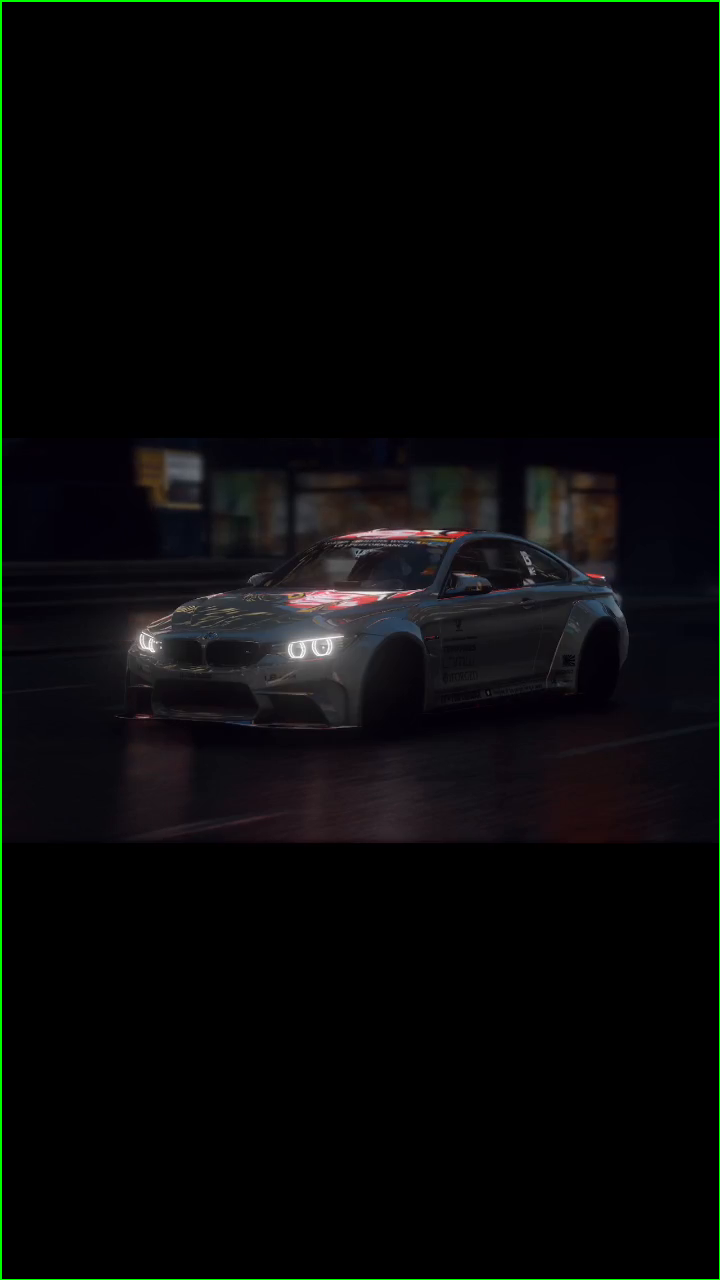

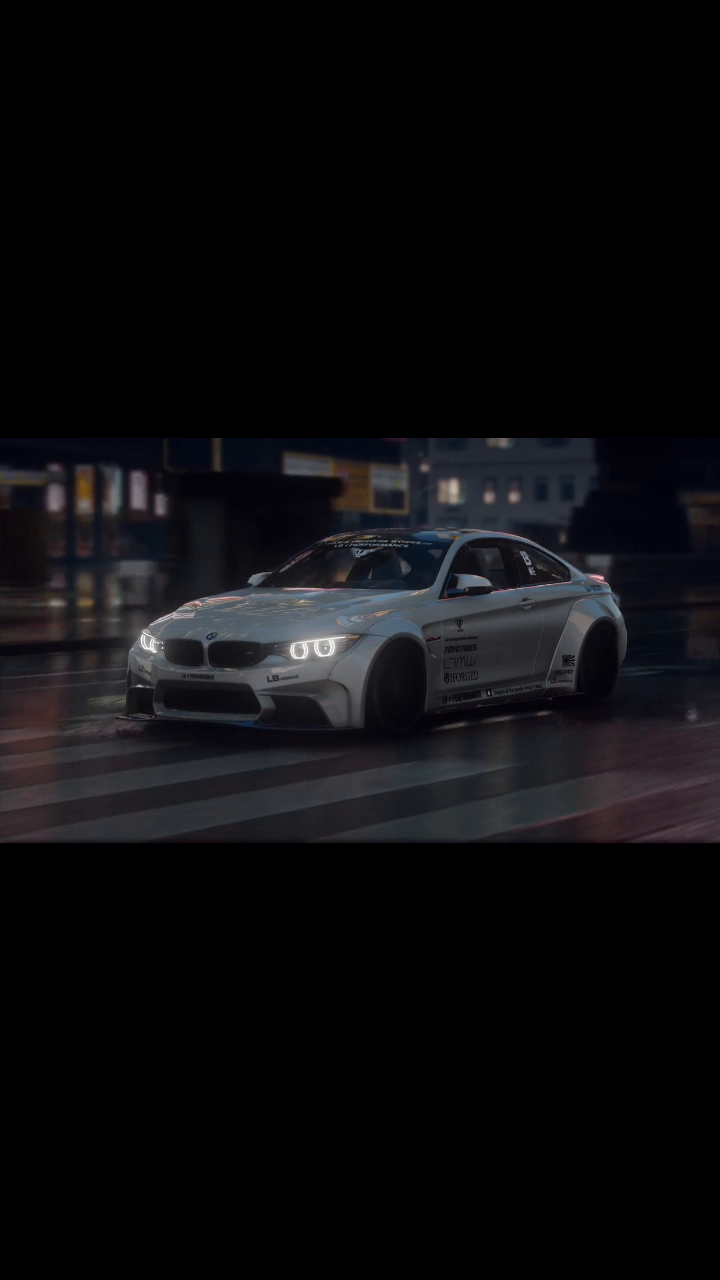

In [1]:

import cv2
import numpy as np
from google.colab.patches import cv2_imshow


def calculate_speed(flow, scale_factor, fps):
    magnitudes = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)
    avg_magnitude = np.mean(magnitudes)
    speed_m_per_s = avg_magnitude * scale_factor * fps
    speed_km_per_h = speed_m_per_s * 3.6
    return speed_km_per_h


def detect_vehicles(frame, fg_mask):
    contours, _ = cv2.findContours(fg_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    vehicle_contours = []

    for contour in contours:
        if cv2.contourArea(contour) > 1000:
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = w / float(h)

            if 1.2 > aspect_ratio > 0.3:
                vehicle_contours.append((x, y, w, h))

    return vehicle_contours


def draw_bounding_box(frame, vehicles, flow, scale_factor, fps):
    for (x, y, w, h) in vehicles:
        roi_flow = flow[y:y+h, x:x+w]
        speed = calculate_speed(roi_flow, scale_factor, fps)

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)

        cv2.putText(frame,
                    f"{speed:.2f} km/h",
                    (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,0),
                    2)


def main(video_path, scale_factor, fps):

    cap = cv2.VideoCapture(video_path)

    ret, prev_frame = cap.read()
    if not ret:
        print("Error reading video")
        return

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    background_subtractor = cv2.createBackgroundSubtractorMOG2()

    frame_count = 0

    while cap.isOpened():

        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            gray,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        fg_mask = background_subtractor.apply(gray)

        vehicles = detect_vehicles(frame, fg_mask)

        draw_bounding_box(frame, vehicles, flow, scale_factor, fps)

        if frame_count % 30 == 0:
            cv2_imshow(frame)

        frame_count += 1
        prev_gray = gray.copy()

    cap.release()


scale_factor = 0.05
fps = 30

video_path = "/content/InShot_20260311_122838844.mp4"   # change to your video path

main(video_path, scale_factor, fps)